In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('endurance_motec_export.csv')

print(df.shape)
print(df['Time'].min(), df['Time'].max())
print("Duration (min):", (df['Time'].max() - df['Time'].min()) / 60)
print(df.columns.tolist())

(318886, 60)
0.0 3188.85
Duration (min): 53.1475
['Time', 'Car DigitalInput MSS PDOC Pin', 'Car DigitalInput MSS BMS Pin', 'Car DigitalInput MSS BSPD Pin', 'Car DigitalInput MSS IMD Pin', 'Car Data Driver ThrottlePressure', 'Car Data Motor MotorRPM', 'Car AnalogInput BMS CellTempASensor', 'Car AnalogInput BMS CellTempBSensor', 'Car AnalogInput BMS CellTempCSensor', 'Car Data Battery PackSOC', 'Car Data PDM LVBatteryVoltage', 'Car Data Battery BMSInternalTemp', 'Car Data Inverter InverterTemp', 'Car Data Motor MotorTemp', 'Car Data Inverter InverterLock', 'Car Data Driver Speed', 'Car Data Water WaterTempOut', 'Car Data Driver SteeringAngle', 'Car Data Driver FrontBrakePressure', 'Car Data Driver RearBrakePressure', 'Car Data Driver ThrottleDifference', 'Car Data Battery HotSpotTemp', 'Car Data Water WaterPressureIn', 'Car Data Water WaterPressureOut', 'Car Data Water WaterTempIn', 'Car Data Battery PackInstantaneousVoltage', 'Car Data Battery PackOpenVoltage', 'Car Data Battery PackCur

In [3]:
# Standardizing units

for col in ['Car Data Battery PackInstantaneousVoltage',
            'Car Data Battery PackCurrent',
            'Car Data Battery HighCellVoltage',
            'Car Data Battery BatteryPower']:
    print(col)
    print(df[col].describe())
    print()

V_raw = df['Car Data Battery PackInstantaneousVoltage']
I_raw = df['Car Data Battery PackCurrent']

corr = df['Car Data Battery BatteryPower'].corr(V_raw * I_raw)
print("corr(BatteryPower, V_raw*I_raw):", corr)

V_actual = V_raw / 10
I_actual = I_raw / 10

Car Data Battery PackInstantaneousVoltage
count    318213.000000
mean       4025.763467
std         470.045319
min           0.000000
25%        3931.000000
50%        4083.000000
75%        4208.000000
max        4350.000000
Name: Car Data Battery PackInstantaneousVoltage, dtype: float64

Car Data Battery PackCurrent
count    318213.000000
mean         98.616537
std         119.264305
min         -83.000000
25%           0.000000
50%          68.000000
75%         155.000000
max        1272.000000
Name: Car Data Battery PackCurrent, dtype: float64

Car Data Battery HighCellVoltage
count    318196.000000
mean      37784.534545
std        4411.959017
min           0.000000
25%       36908.000000
50%       38232.000000
75%       39610.000000
max       40784.000000
Name: Car Data Battery HighCellVoltage, dtype: float64

Car Data Battery BatteryPower
count    3.182130e+05
mean     3.913688e+05
std      4.553518e+05
min     -3.205460e+05
25%      0.000000e+00
50%      2.847600e+05
75%      

In [4]:
# Convert Power in Watts

P_watts = df['Car Data Battery BatteryPower'].fillna(0) / 100.0

print(P_watts.describe())

count    318886.000000
mean       3905.428578
std        4552.254899
min       -3205.460000
25%           0.000000
50%        2833.405000
75%        6291.480000
max       45893.760000
Name: Car Data Battery BatteryPower, dtype: float64


In [5]:
# Integrate to get total energy

t = df['Time'].values
dt = np.diff(t, prepend=t[0] - 0.01)

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

E_net_kWh = trapz(P_watts.values, t) / 3.6e6
print("Net energy (kWh):", E_net_kWh)

P_discharge = np.clip(P_watts.values, 0, None)
P_regen = np.clip(P_watts.values, None, 0)

E_discharge_kWh = trapz(P_discharge, t) / 3.6e6
E_regen_kWh = -trapz(P_regen, t) / 3.6e6

print("Gross discharged (kWh):", E_discharge_kWh)
print("Regen recovered (kWh):", E_regen_kWh)

Net energy (kWh): 3.459406937416663
Gross discharged (kWh): 3.4657941846388853
Regen recovered (kWh): 0.006387247222222439


In [7]:
# Cross-checking

soc = df['Car Data Battery PackSOC']
soc_start = soc.dropna().iloc[0]
soc_end = soc.dropna().iloc[-1]

implied_capacity_kWh = E_net_kWh / (soc_start - soc_end) * 100
print("SOC drop:", soc_start, "->", soc_end)
print("Implied pack capacity (kWh):", implied_capacity_kWh)

Vinv_actual = df['Car Data Inverter InverterDCVoltage'].fillna(0) / 10
Iinv_actual = df['Car Data Inverter InverterDCCurrent'].fillna(0) / 10
P_inv = Vinv_actual * Iinv_actual

E_inv_kWh = trapz(P_inv.values, t) / 3.6e6
print("Inverter-side energy (kWh):", E_inv_kWh)
print("Diff vs pack-side (%):", 100 * (E_inv_kWh - E_net_kWh) / E_net_kWh)

SOC drop: 0.0 -> 34.0
Implied pack capacity (kWh): -10.174726286519597
Inverter-side energy (kWh): 3.441384173611114
Diff vs pack-side (%): -0.5209784258283132


In [8]:
# Finding driving stints

speed = df['Car Data Driver Speed'].fillna(0).values
zero = speed <= 1

runs = []
in_run, start = False, None
for idx in range(len(df)):
    if zero[idx] and not in_run:
        in_run, start = True, idx
    elif not zero[idx] and in_run:
        in_run = False
        dur = t[idx - 1] - t[start]
        if dur > 15:
            runs.append((t[start], t[idx - 1], dur))
if in_run:
    runs.append((t[start], t[-1], t[-1] - t[start]))

print("Long stops (>15s):", runs)

stint_bounds = []
prev_end = 0
for s, e, d in runs:
    if s - prev_end > 30:
        stint_bounds.append((prev_end, s))
    prev_end = e
if t[-1] - prev_end > 30:
    stint_bounds.append((prev_end, t[-1]))

stints = []
for s, e in stint_bounds:
    m = (t >= s) & (t <= e) & (speed > 1)
    if m.sum() > 100:
        stints.append((t[m].min(), t[m].max()))

print("Stints:", stints)

Long stops (>15s): [(np.float64(0.0), np.float64(268.29), np.float64(268.29)), (np.float64(1676.9), np.float64(1743.79), np.float64(66.88999999999987)), (np.float64(3038.0), np.float64(3115.09), np.float64(77.09000000000015)), (np.float64(3149.9), np.float64(3188.85), np.float64(38.94999999999982))]
Stints: [(np.float64(268.3), np.float64(1676.89)), (np.float64(1743.8), np.float64(3037.99)), (np.float64(3115.1), np.float64(3149.89))]


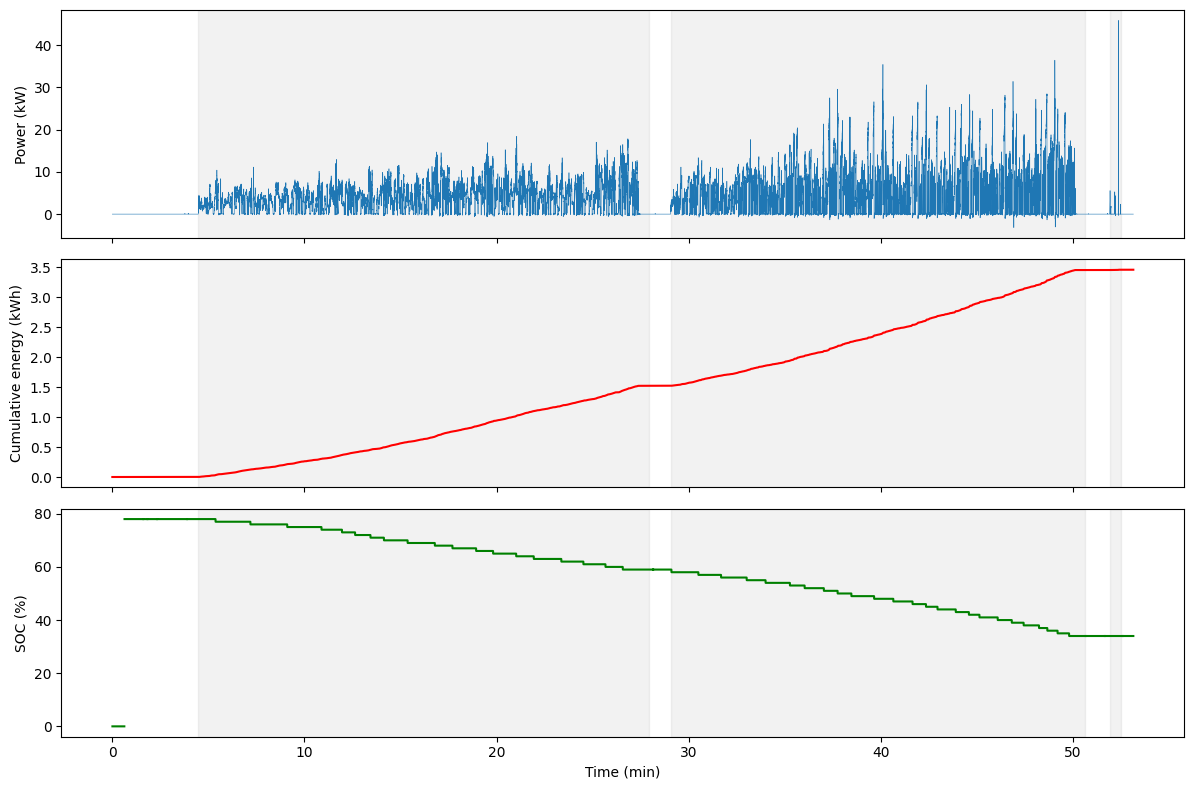

In [10]:
# Plot power

cum_E_kWh = np.concatenate([[0], np.cumsum(
    (P_watts.values[1:] + P_watts.values[:-1]) / 2 * np.diff(t))]) / 3.6e6

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t/60, P_watts.values/1000, lw=0.4)
axes[0].set_ylabel("Power (kW)")

axes[1].plot(t/60, cum_E_kWh, color='red')
axes[1].set_ylabel("Cumulative energy (kWh)")

axes[2].plot(t/60, soc.values, color='green')
axes[2].set_ylabel("SOC (%)")
axes[2].set_xlabel("Time (min)")

for ax in axes:
    for s, e in stints:
        ax.axvspan(s/60, e/60, color='grey', alpha=0.1)

plt.tight_layout()
plt.show()

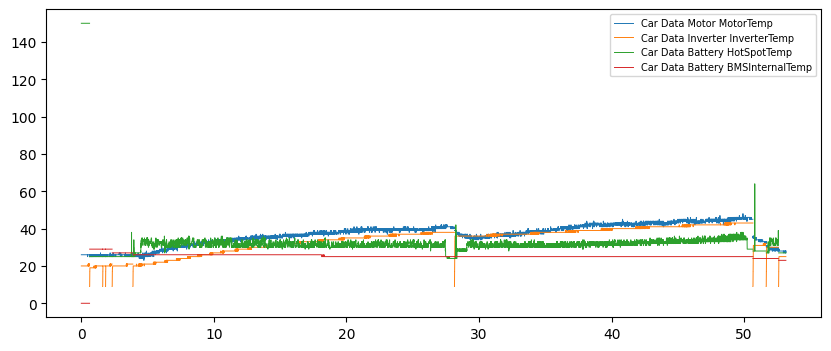

Fan current unique: [nan  0.]
Pump current unique: [nan  0.]


In [12]:
# Thermal insights

fig, ax = plt.subplots(figsize=(10, 4))
for col in ['Car Data Motor MotorTemp', 'Car Data Inverter InverterTemp',
            'Car Data Battery HotSpotTemp', 'Car Data Battery BMSInternalTemp']:
    ax.plot(t/60, df[col], label=col, lw=0.7)
ax.legend(fontsize=7)
plt.show()

print("Fan current unique:", df['Car Data PDM CoolingFanCurrent'].unique())
print("Pump current unique:", df['Car Data PDM CoolingPumpCurrent'].unique())

Stint1 kWh: 1.5219753042222217 km: 12.884633333331953 Wh/km: 118.1232918972511
Stint2 kWh: 1.9319836587499972 km: 12.81491111111064 Wh/km: 150.7605977129994


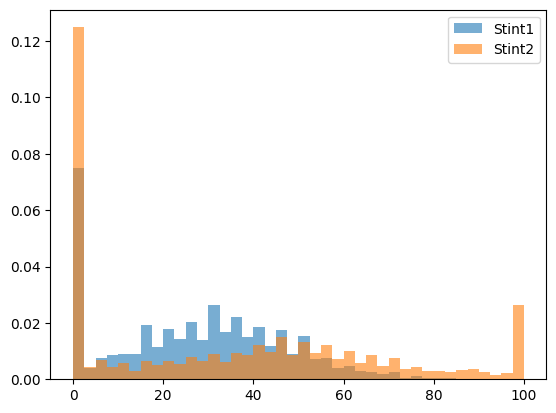

In [13]:
# Driver/stint comparison

s1 = (t >= stints[0][0]) & (t <= stints[0][1])
s2 = (t >= stints[1][0]) & (t <= stints[1][1])

dist_km = np.concatenate([[0], np.cumsum(
    (speed[1:] + speed[:-1]) / 2 * np.diff(t) / 3600)])

for name, m in [('Stint1', s1), ('Stint2', s2)]:
    e = trapz(P_watts.values[m], t[m]) / 3.6e6
    d = dist_km[t <= t[m].max()][-1] - dist_km[t <= t[m].min()][-1]
    print(name, "kWh:", e, "km:", d, "Wh/km:", e/d*1000)

throttle = df['Car Data Driver ThrottlePressure'].values
plt.hist(throttle[s1], bins=40, alpha=0.6, label='Stint1', density=True)
plt.hist(throttle[s2], bins=40, alpha=0.6, label='Stint2', density=True)
plt.legend()
plt.show()

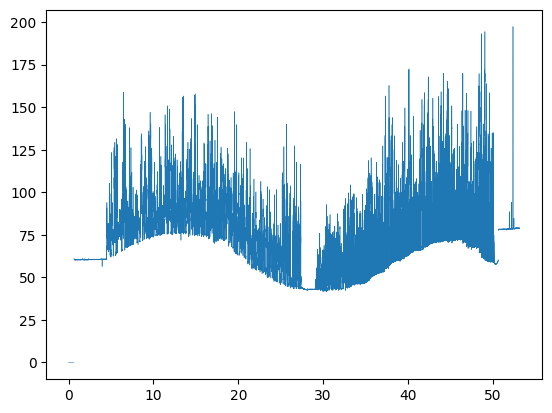

% session current-limited: 33.18301838274493


In [14]:
# Battery health

hv = df['Car Data Battery HighCellVoltage'] / 10000
lv = df['Car Data Battery LowCellVoltage'] / 10000
imbalance_mV = (hv - lv) * 1000
plt.plot(t/60, imbalance_mV, lw=0.4)
plt.show()

cls = df['Car Data Battery CurrentLimitsStatus']
print("% session current-limited:", 100 * (cls != 0).mean())

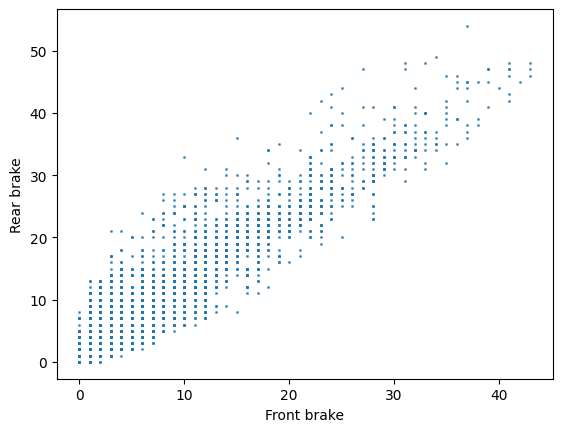

In [15]:
# Brake health

fb = df['Car Data Driver FrontBrakePressure']
rb = df['Car Data Driver RearBrakePressure']
plt.scatter(fb, rb, s=1, alpha=0.1)
plt.xlabel('Front brake'); plt.ylabel('Rear brake')
plt.show()